# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
aviation_df = pd.read_csv("data/AviationData_Clean.csv", low_memory=False)

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [4]:

# Separate aircraft by estimated capacity
# Create an aircraft size classification based on estimated occupants
aviation_df["Aircraft.Size"] = np.where(
    aviation_df["Total.Occupants"] < 20,
    "Small Aircraft",
    "Large Passenger Aircraft"
)

# Create separate DataFrames
small_aircraft_df = aviation_df[
    aviation_df["Aircraft.Size"] == "Small Aircraft"
].copy()

large_aircraft_df = aviation_df[
    aviation_df["Aircraft.Size"] == "Large Passenger Aircraft"
].copy()

# Inspect the split
print("Aircraft size distribution:")
display(aviation_df["Aircraft.Size"].value_counts())

print(f"\nSmall aircraft records: {small_aircraft_df.shape[0]}")
print(f"Large passenger aircraft records: {large_aircraft_df.shape[0]}")


Aircraft size distribution:


Aircraft.Size
Small Aircraft              17001
Large Passenger Aircraft      878
Name: count, dtype: int64


Small aircraft records: 17001
Large passenger aircraft records: 878


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

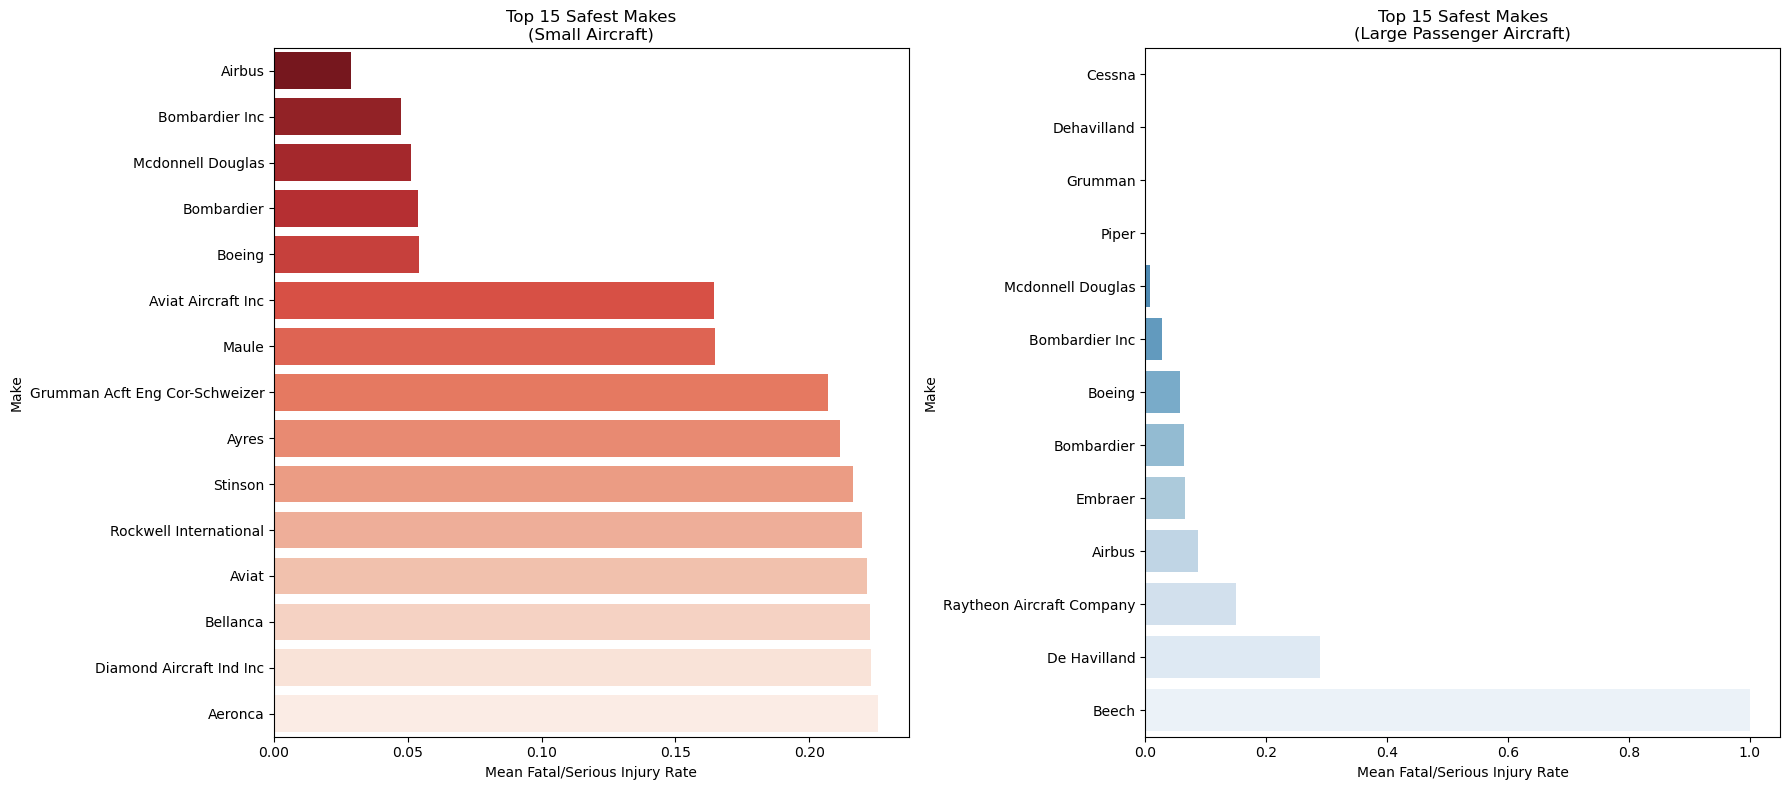

,Make,Fatal.Serious.Rate
0,Airbus,0.028706
1,Bombardier Inc,0.047619
2,Mcdonnell Douglas,0.051299
3,Bombardier,0.053714
4,Boeing,0.054085
5,Aviat Aircraft Inc,0.164474
6,Maule,0.164806
7,Grumman Acft Eng Cor-Schweizer,0.206897
8,Ayres,0.211538
9,Stinson,0.216408


,Make,Fatal.Serious.Rate
0,Cessna,0.000000
1,Dehavilland,0.000000
2,Grumman,0.000000
3,Piper,0.000000
4,Mcdonnell Douglas,0.007827
5,Bombardier Inc,0.028038
6,Boeing,0.056771
7,Bombardier,0.063701
8,Embraer,0.065274
9,Airbus,0.086249


In [8]:
# Top 15 safest aircraft makes
# (based on mean fatal/serious injury rate)


# Compute mean injury rate by make
small_make_risk = (
    small_aircraft_df
    .groupby("Make")["Fatal.Serious.Rate"]
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)

large_make_risk = (
    large_aircraft_df
    .groupby("Make")["Fatal.Serious.Rate"]
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(
    data=small_make_risk,
    x="Fatal.Serious.Rate",
    y="Make",
    hue="Make",
    palette="Reds_r",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Top 15 Safest Makes\n(Small Aircraft)")
axes[0].set_xlabel("Mean Fatal/Serious Injury Rate")
axes[0].set_ylabel("Make")

sns.barplot(
    data=large_make_risk,
    x="Fatal.Serious.Rate",
    y="Make",
    hue="Make",
    palette="Blues_r",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Top 15 Safest Makes\n(Large Passenger Aircraft)")
axes[1].set_xlabel("Mean Fatal/Serious Injury Rate")
axes[1].set_ylabel("Make")

plt.tight_layout()
plt.show()

# Display the summary tables
display(small_make_risk)
display(large_make_risk)


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

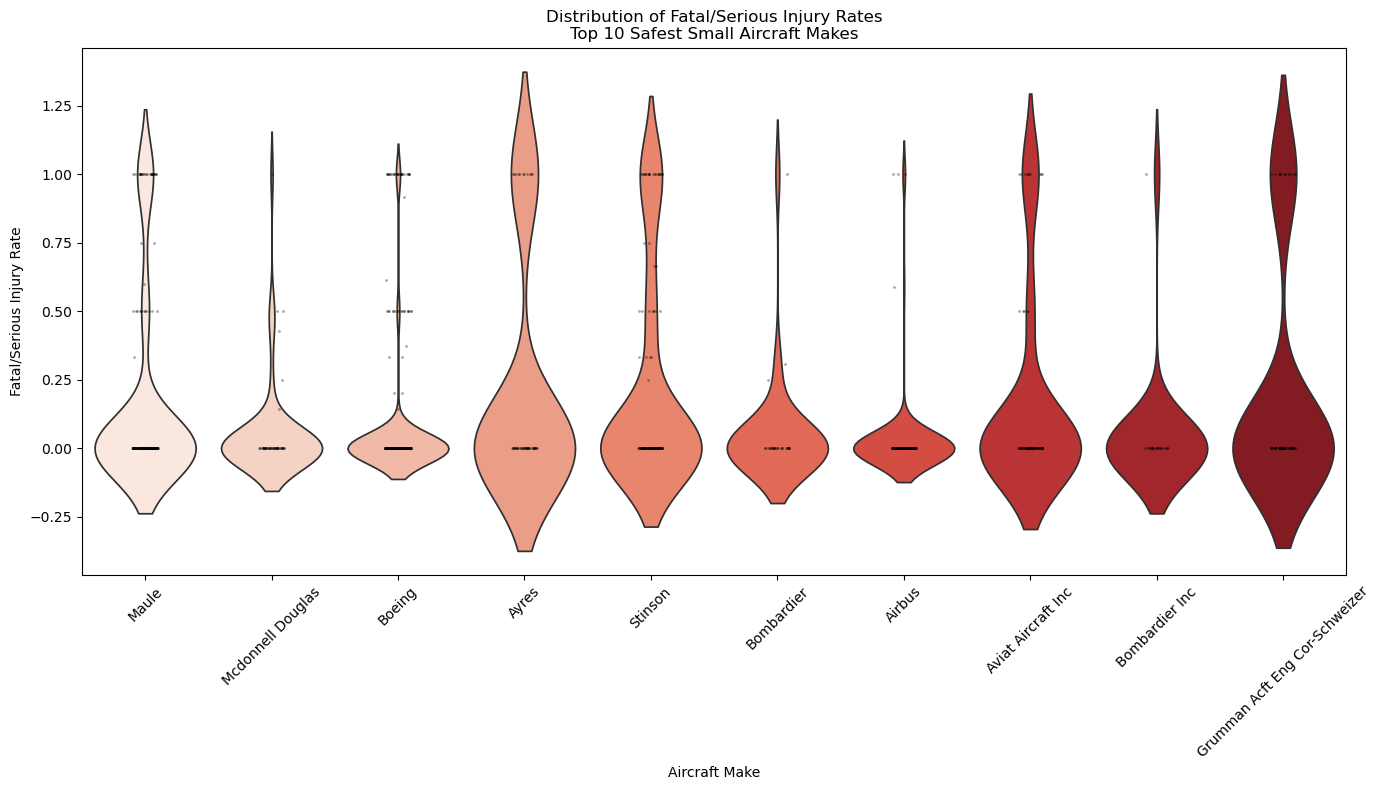

In [9]:
# Distribution of injury rates:
# Top 10 safest small aircraft makes

# Identify the 10 makes with the lowest mean fatal/serious injury rate
top10_small_makes = (
    small_aircraft_df
    .groupby("Make")["Fatal.Serious.Rate"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

# Filter the dataset
small_top10_df = small_aircraft_df[
    small_aircraft_df["Make"].isin(top10_small_makes)
]

# Create the plot
plt.figure(figsize=(14, 8))

# Violin plot (distribution)
sns.violinplot(
    data=small_top10_df,
    x="Make",
    y="Fatal.Serious.Rate",
    hue="Make",
    palette="Reds",
    legend=False,
    inner=None  # Prevents duplicate markings inside the violins
)

# Overlay the actual observations
sns.stripplot(
    data=small_top10_df,
    x="Make",
    y="Fatal.Serious.Rate",
    color="black",
    size=2,
    alpha=0.35,
    jitter=True
)

plt.title("Distribution of Fatal/Serious Injury Rates\nTop 10 Safest Small Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal/Serious Injury Rate")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

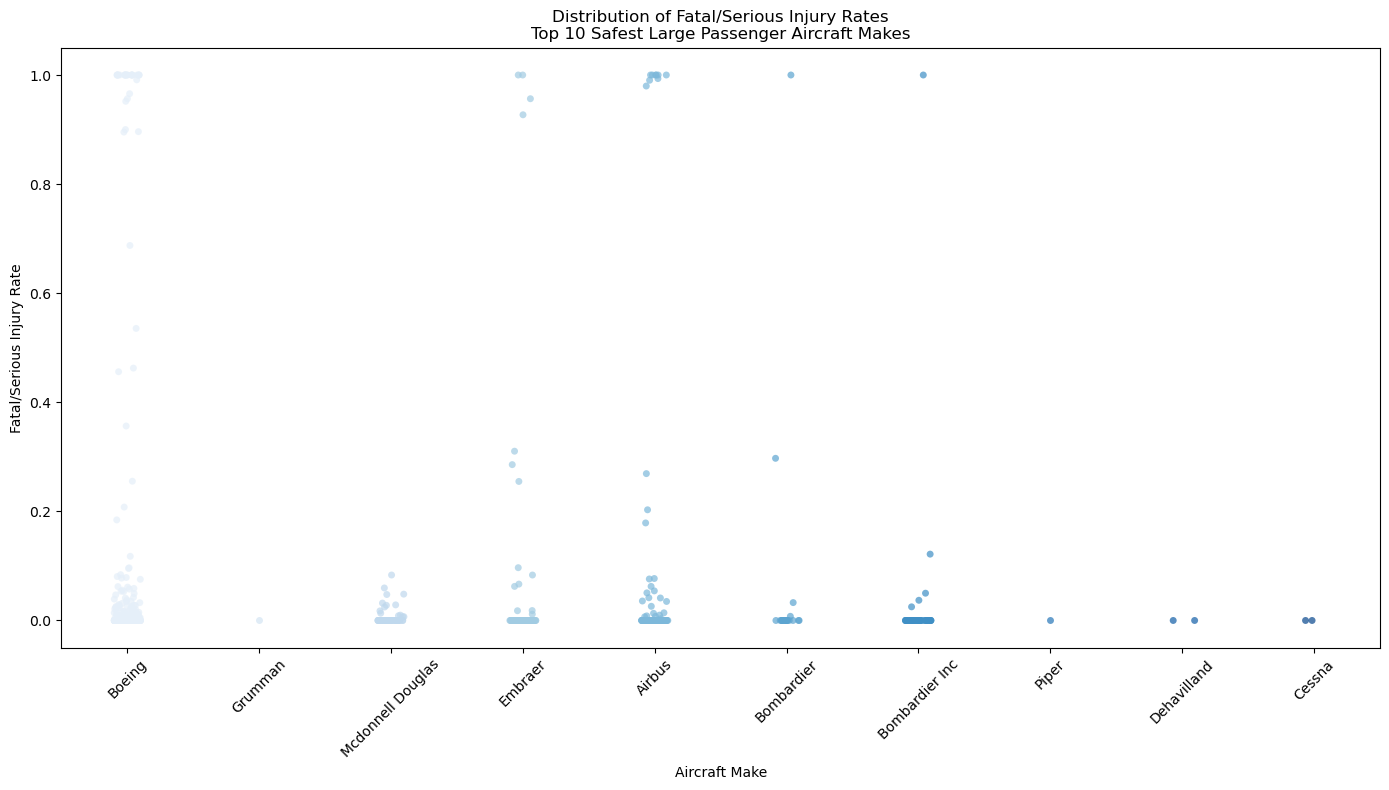

In [11]:
# Distribution of injury rates:
# Top 10 safest large aircraft makes
#Identify the 10 makes with the lowest mean fatal/serious injury rate
top10_large_makes = (
    large_aircraft_df
    .groupby("Make")["Fatal.Serious.Rate"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

# Filter the dataset
large_top10_df = large_aircraft_df[
    large_aircraft_df["Make"].isin(top10_large_makes)
]

# Create the strip plot
plt.figure(figsize=(14, 8))

sns.stripplot(
    data=large_top10_df,
    x="Make",
    y="Fatal.Serious.Rate",
    hue="Make",
    palette="Blues",
    legend=False,
    jitter=True,
    size=5,
    alpha=0.7
)

plt.title("Distribution of Fatal/Serious Injury Rates\nTop 10 Safest Large Passenger Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal/Serious Injury Rate")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

Top 15 Small Aircraft Makes (Lowest Destruction Rate)


,Make,Destroyed
0,Luscombe,0.014184
1,Grumman Acft Eng Cor-Schweizer,0.017241
2,Stinson,0.023256
3,Airbus,0.024000
4,Taylorcraft,0.032258
5,Bombardier,0.034483
6,Aeronca,0.035000
7,Boeing,0.036415
8,Ercoupe,0.038462
9,American Champion Aircraft,0.038462


Top 15 Large Passenger Aircraft Makes (Lowest Destruction Rate)


,Make,Destroyed
0,Cessna,0.000000
1,Dehavilland,0.000000
2,Grumman,0.000000
3,Piper,0.000000
4,Raytheon Aircraft Company,0.000000
5,Bombardier Inc,0.022727
6,Bombardier,0.047619
7,Boeing,0.049360
8,Embraer,0.051282
9,Mcdonnell Douglas,0.075472


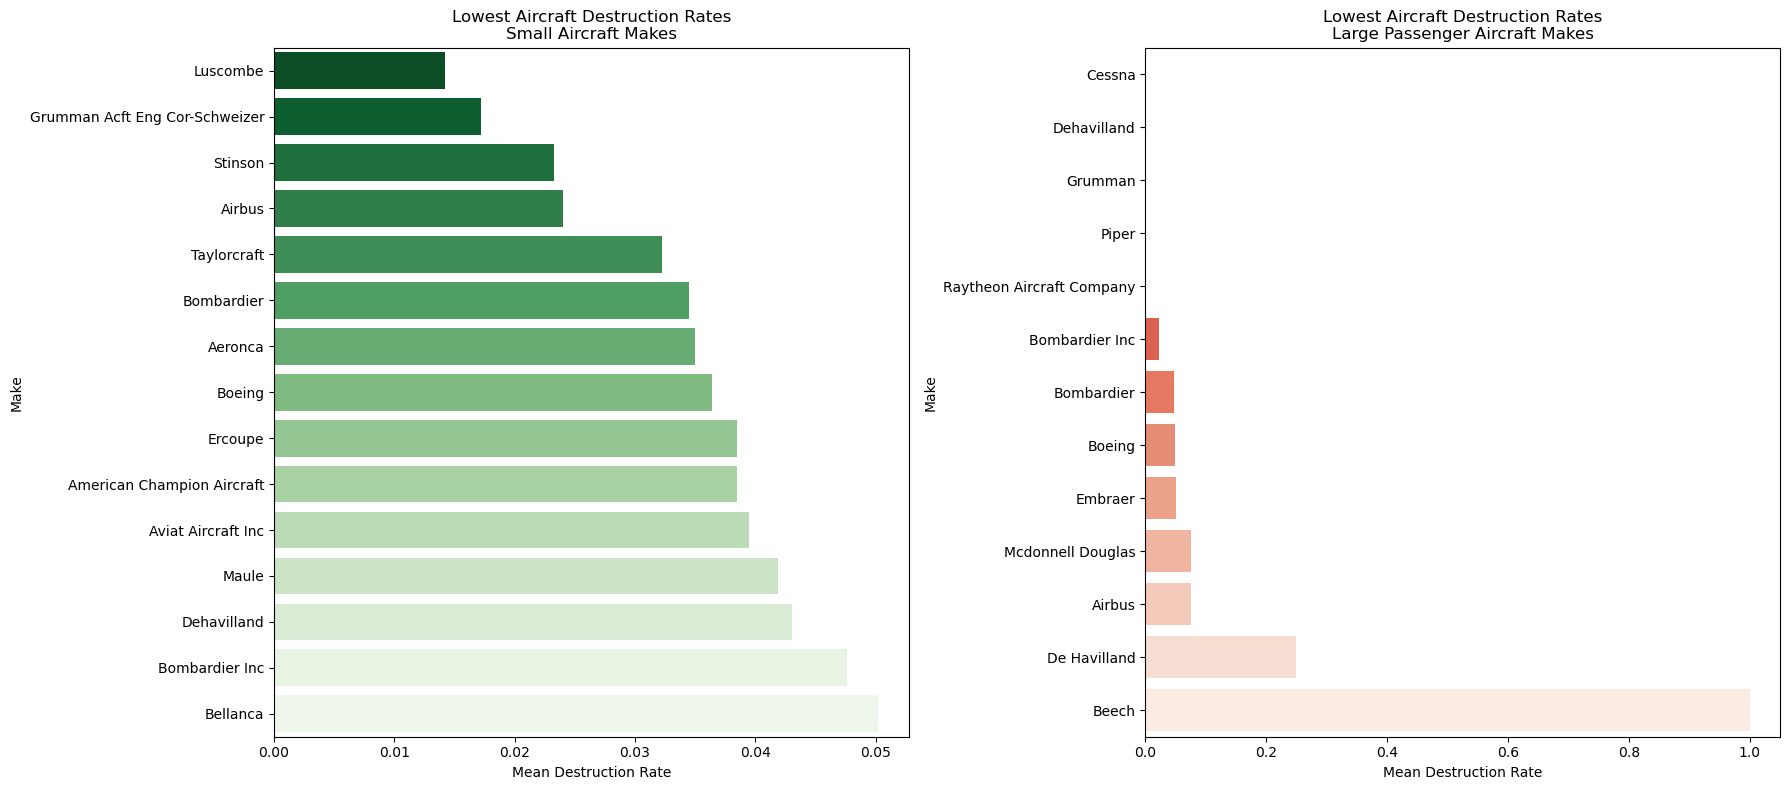

In [15]:
# Aircraft destruction rate by Make
# Calculate mean destruction rate for small aircraft makes
small_make_destroyed = (
    small_aircraft_df
    .groupby("Make")["Destroyed"]
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)

# Calculate mean destruction rate for large aircraft makes
large_make_destroyed = (
    large_aircraft_df
    .groupby("Make")["Destroyed"]
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)

# Display summary tables
print("Top 15 Small Aircraft Makes (Lowest Destruction Rate)")
display(small_make_destroyed)

print("Top 15 Large Passenger Aircraft Makes (Lowest Destruction Rate)")
display(large_make_destroyed)

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Small aircraft
sns.barplot(
    data=small_make_destroyed,
    x="Destroyed",
    y="Make",
    hue="Make",
    palette="Greens_r",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Lowest Aircraft Destruction Rates\nSmall Aircraft Makes")
axes[0].set_xlabel("Mean Destruction Rate")
axes[0].set_ylabel("Make")

# Large passenger aircraft
sns.barplot(
    data=large_make_destroyed,
    x="Destroyed",
    y="Make",
    hue="Make",
    palette="Reds_r",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Lowest Aircraft Destruction Rates\nLarge Passenger Aircraft Makes")
axes[1].set_xlabel("Mean Destruction Rate")
axes[1].set_ylabel("Make")

plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

### Discussion of Make-Level Results

The manufacturer-level analysis assessed aircraft safety using two key indicators: the average fatal/serious injury rate and the proportion of accidents in which the aircraft was completely destroyed. Considering both measures provides a broader understanding of safety performance than relying on a single metric.

For small aircraft, manufacturers such as Airbus, Bombardier, Bombardier Inc, Boeing, and Grumman Acft Eng Cor-Schweizer recorded some of the lowest average fatal/serious injury rates. The distribution of injury rates also showed that accidents involving these manufacturers were generally clustered around low values, indicating that most incidents resulted in relatively few serious or fatal injuries, despite a small number of more severe accidents.

A similar pattern was observed when examining aircraft destruction rates. Airbus, Bombardier, Bombardier Inc, Boeing, and Maule had comparatively low proportions of accidents that resulted in total aircraft destruction. Since several manufacturers performed well on both injury outcomes and destruction rates, there is stronger evidence that they demonstrate consistently favorable safety characteristics.

For larger passenger aircraft, the findings require more careful interpretation. Some manufacturers, including Cessna, Piper, and Grumman, displayed very low injury and destruction rates; however, these results are based on a smaller number of recorded accidents within the large-aircraft category. Greater confidence can therefore be placed in manufacturers with stronger representation in the dataset, such as Airbus, Boeing, Bombardier, Bombardier Inc, and McDonnell Douglas. The strip plot further indicates that the majority of accidents involving these manufacturers resulted in low fatal/serious injury rates, although a limited number of high-severity events were still present.

### Recommendations

Based on the combined evaluation of occupant injury outcomes and aircraft destruction rates, the following manufacturers are recommended:

**Small Aircraft**

* Airbus
* Bombardier
* Bombardier Inc
* Boeing
* Maule

These manufacturers consistently achieved lower average fatal/serious injury rates while also recording relatively low aircraft destruction rates, making them strong choices for small-aircraft operations.

**Large Passenger Aircraft**

* Airbus
* Boeing
* Bombardier
* Bombardier Inc
* McDonnell Douglas

These manufacturers performed consistently well across both safety measures and were supported by a sufficient number of accident records, making them suitable recommendations for larger passenger aircraft.

### Overall Conclusion

Evaluating both passenger injury severity and aircraft destruction provides a more complete assessment of aviation safety. Manufacturers that consistently rank well across both indicators offer stronger evidence of reliable safety performance than those that perform well on only one measure.


### conclusion

Aircraft safety was evaluated using two key measures: the average fatal/serious injury rate and the rate of aircraft destruction. These metrics were used to identify manufacturers and aircraft models with stronger safety performance while also examining how operational factors may influence accident severity. The sections that follow present the detailed findings, recommendations, and supporting evidence based on the analysis.


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

,Make_Model,Mean_Injury_Rate,Accident_Count
0,Airbus A321,0.000000,10
1,Airbus A330,0.000000,16
2,Maule M-5-210C,0.000000,11
3,Boeing 737-800,0.000000,12
4,Boeing 777,0.000000,43
5,Boeing 787,0.000000,14
6,Boeing 737,0.012500,240
7,Airbus A320,0.018182,55
8,Boeing 747,0.035088,57
9,Boeing 757,0.041667,24


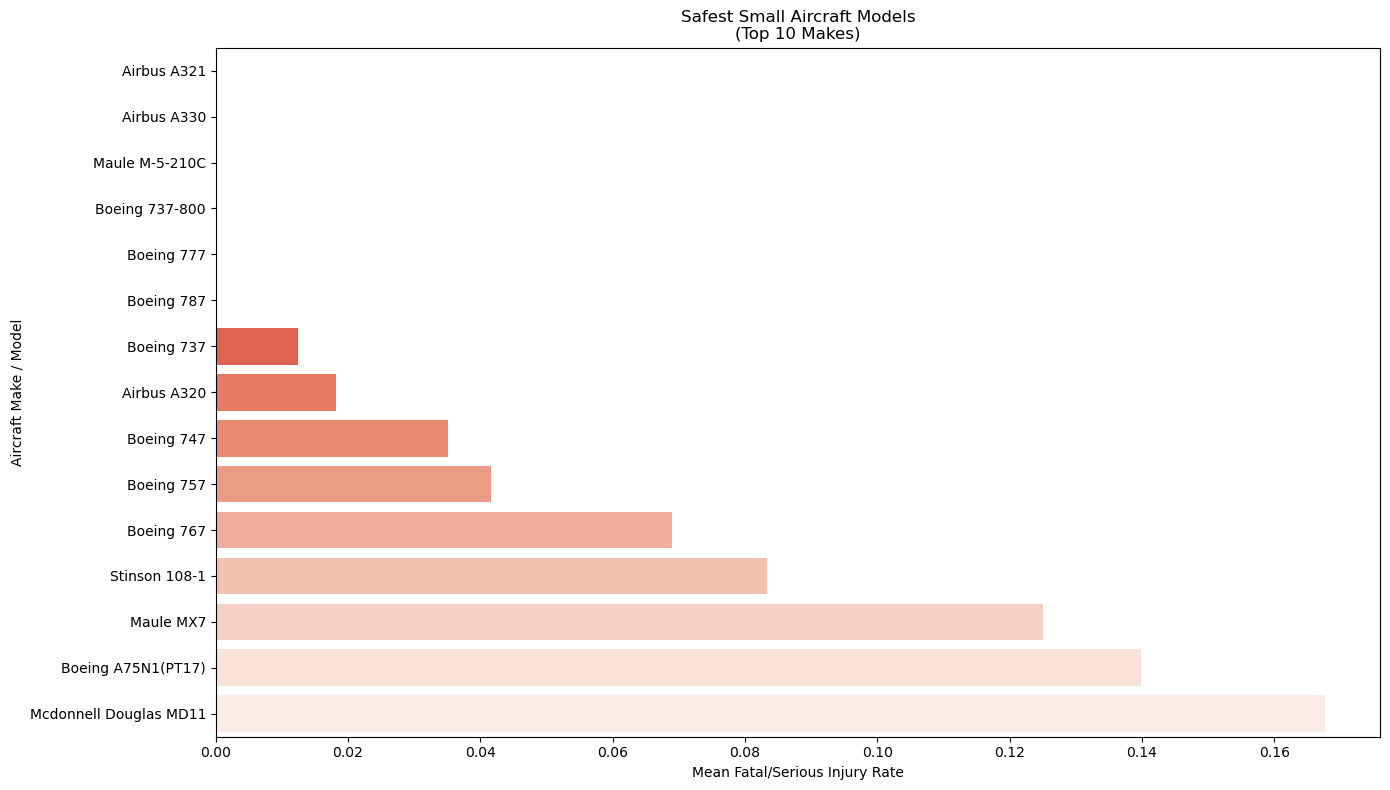

In [17]:
# Model-level analysis for small aircraft
# Top 10 safest makes only


# Get the 10 safest small-aircraft makes
top10_small_makes = (
    small_aircraft_df
    .groupby("Make")["Fatal.Serious.Rate"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

# Filter to only those makes
small_top10_df = small_aircraft_df[
    small_aircraft_df["Make"].isin(top10_small_makes)
]

# Calculate model-level injury rates
small_model_risk = (
    small_top10_df
    .assign(Make_Model=small_top10_df['Make'] + ' ' + small_top10_df['Model'])
    .groupby("Make_Model")
    .agg(
        Mean_Injury_Rate=("Fatal.Serious.Rate", "mean"),
        Accident_Count=("Fatal.Serious.Rate", "count")
    )
    .query("Accident_Count >= 10")
    .sort_values("Mean_Injury_Rate")
    .head(15)
    .reset_index()
)

display(small_model_risk)

# Plot
plt.figure(figsize=(14,8))

sns.barplot(
    data=small_model_risk,
    x="Mean_Injury_Rate",
    y="Make_Model",
    hue="Make_Model",
    palette="Reds_r",
    legend=False
)

plt.title("Safest Small Aircraft Models\n(Top 10 Makes)")
plt.xlabel("Mean Fatal/Serious Injury Rate")
plt.ylabel("Aircraft Make / Model")

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

,Make_Model,Mean_Injury_Rate,Accident_Count
0,Boeing 777,0.000821,33
1,Boeing 757,0.001473,18
2,Boeing 787,0.003058,11
3,Boeing 737-7H4,0.003242,12
4,Bombardier Inc CL-600-2B19,0.004136,15
5,Embraer EMB145,0.008798,11
6,Embraer EMB-145LR,0.010000,15
7,Boeing 747,0.023161,11
8,Boeing 767,0.046963,31
9,Boeing 737 7H4,0.068121,14


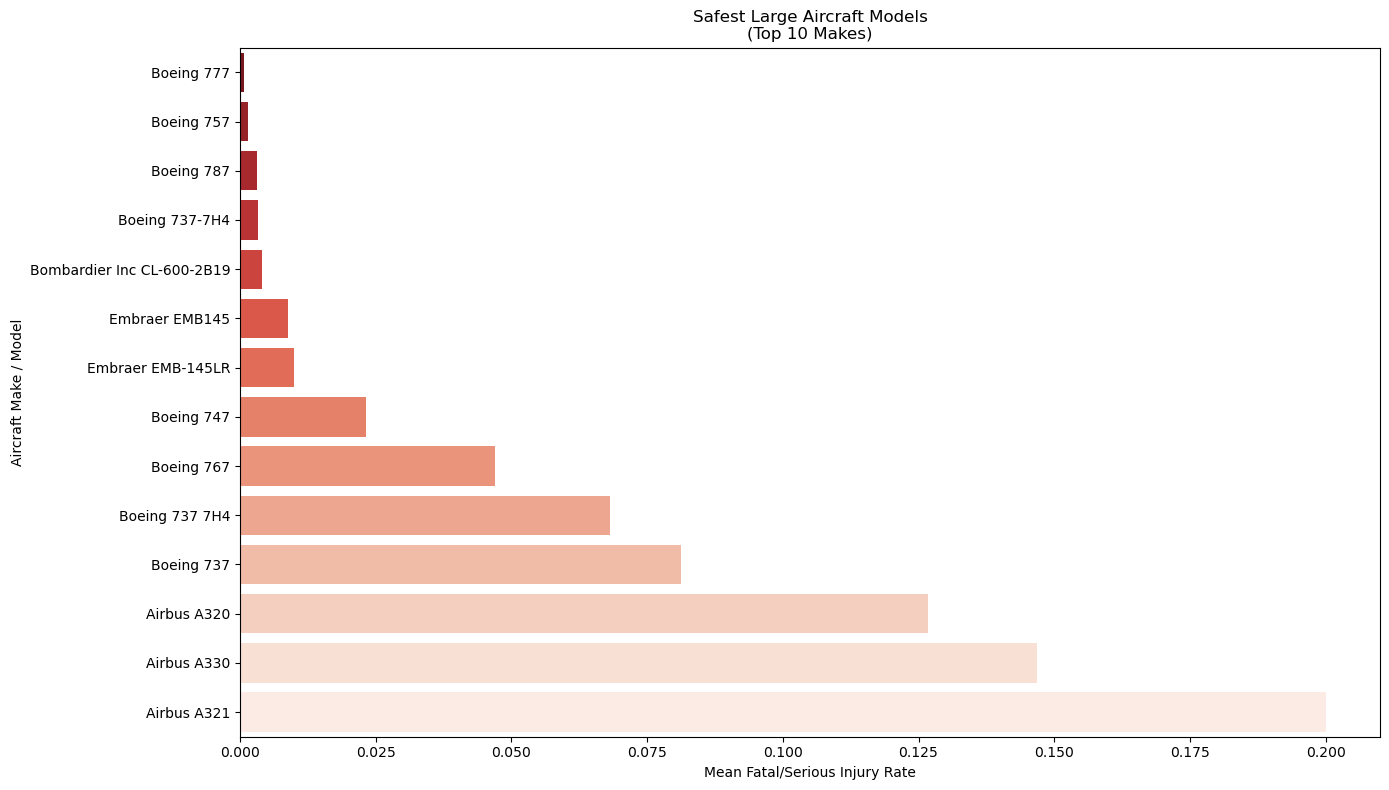

In [19]:
# Model-level analysis for large aircraft
# Top 10 safest makes only


# Get the 10 safest large-aircraft makes
top10_large_makes = (
    large_aircraft_df
    .groupby("Make")["Fatal.Serious.Rate"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

# Filter to only those makes
large_top10_df = large_aircraft_df[
    large_aircraft_df["Make"].isin(top10_large_makes)
]

# Calculate model-level injury rates
large_model_risk = (
    large_top10_df
    .assign(Make_Model=large_top10_df['Make'] + ' ' + large_top10_df['Model'])
    .groupby("Make_Model")
    .agg(
        Mean_Injury_Rate=("Fatal.Serious.Rate", "mean"),
        Accident_Count=("Fatal.Serious.Rate", "count")
    )
    .query("Accident_Count >= 10")
    .sort_values("Mean_Injury_Rate")
    .head(15)
    .reset_index()
)

display(large_model_risk)

# Plot
plt.figure(figsize=(14,8))

sns.barplot(
    data=large_model_risk,
    x="Mean_Injury_Rate",
    y="Make_Model",
    hue="Make_Model",
    palette="Reds_r",
    legend=False
)

plt.title("Safest Large Aircraft Models\n(Top 10 Makes)")
plt.xlabel("Mean Fatal/Serious Injury Rate")
plt.ylabel("Aircraft Make / Model")

plt.tight_layout()
plt.show()

### Discussion of Specific Aircraft Types

The aircraft model analysis offers a more detailed evaluation of safety by comparing individual airplane models instead of grouping them only by manufacturer. This approach helps identify which specific aircraft types are associated with better passenger safety outcomes.

Within the small-aircraft category, models such as the Boeing 737-800, Boeing 777, Boeing 787, Airbus A321, Airbus A330, and the Maule M-5-210C recorded some of the lowest average fatal/serious injury rates. These results indicate that accidents involving these aircraft generally resulted in a lower proportion of passengers experiencing fatal or serious injuries compared with many other models in the dataset.

For larger passenger aircraft, the Boeing 777, Boeing 757, Boeing 787, Boeing 737-7H4, and the Bombardier Inc CL-600-2B19 ranked among the best-performing models based on their average fatal/serious injury rates. Other aircraft, including the Embraer EMB145, Embraer EMB-145LR, Boeing 747, and Boeing 767, also demonstrated favorable safety outcomes, with consistently low injury rates across the recorded accidents.

Overall, Boeing models appear repeatedly among the highest-performing aircraft in both the small- and large-aircraft categories, suggesting strong safety performance across multiple aircraft families. Airbus aircraft, particularly the A320, A321, and A330 series, also showed consistently positive results. In addition, Bombardier and Embraer models performed well within the large-aircraft category, indicating favorable passenger safety outcomes.

Although the analysis included only aircraft models with a minimum number of recorded accidents to improve statistical reliability, the results should still be interpreted with consideration of sample size. Models supported by a larger number of accident records provide stronger evidence of their safety performance than those represented by relatively few observations. Therefore, the most reliable recommendations are aircraft models that combine low fatal/serious injury rates with a substantial number of recorded accident cases.


### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

,Mean_Injury_Rate,Mean_Destruction_Rate,Accident_Count
Weather.Condition,,,
Vmc,0.232323,0.070864,14295
Unk,0.363708,0.263359,262
Imc,0.621069,0.348066,905


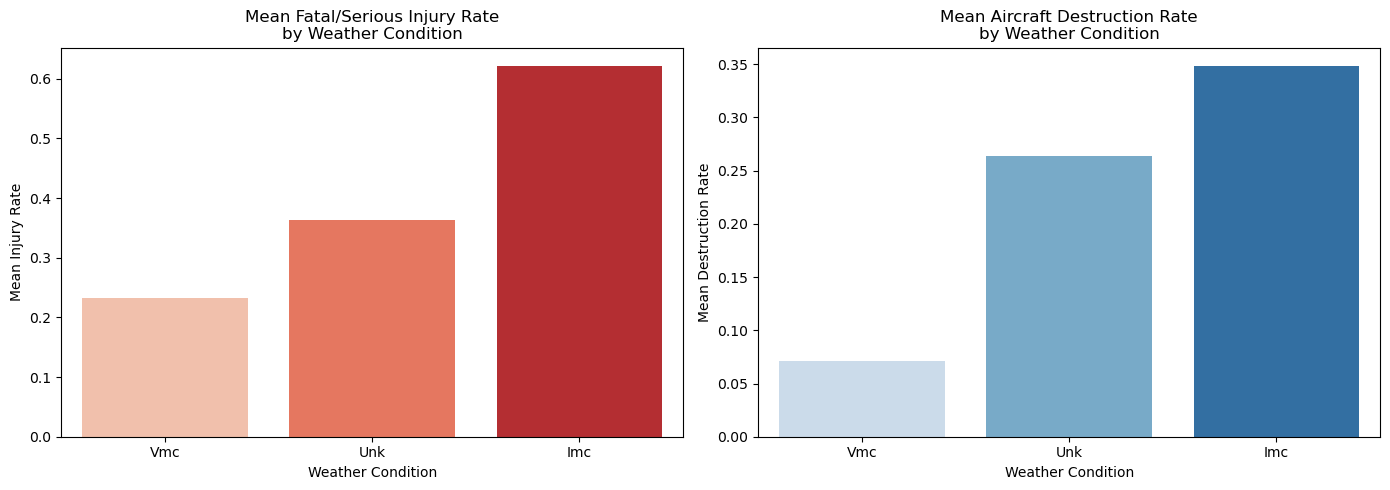

In [20]:
# Weather Condition Analysis


weather_summary = (
    aviation_df
    .groupby("Weather.Condition")
    .agg(
        Mean_Injury_Rate=("Fatal.Serious.Rate", "mean"),
        Mean_Destruction_Rate=("Destroyed", "mean"),
        Accident_Count=("Destroyed", "count")
    )
    .query("Accident_Count >= 20")
    .sort_values("Mean_Injury_Rate")
)

display(weather_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=weather_summary.reset_index(),
    x="Weather.Condition",
    y="Mean_Injury_Rate",
    hue="Weather.Condition",
    legend=False,
    palette="Reds",
    ax=axes[0]
)

axes[0].set_title("Mean Fatal/Serious Injury Rate\nby Weather Condition")
axes[0].set_xlabel("Weather Condition")
axes[0].set_ylabel("Mean Injury Rate")

sns.barplot(
    data=weather_summary.reset_index(),
    x="Weather.Condition",
    y="Mean_Destruction_Rate",
    hue="Weather.Condition",
    legend=False,
    palette="Blues",
    ax=axes[1]
)

axes[1].set_title("Mean Aircraft Destruction Rate\nby Weather Condition")
axes[1].set_xlabel("Weather Condition")
axes[1].set_ylabel("Mean Destruction Rate")

plt.tight_layout()
plt.show()

### Weather Condition

The weather analysis demonstrates that environmental conditions have a significant influence on the severity of aviation accidents. Flights operating under **Visual Meteorological Conditions (VMC)** recorded the lowest average fatal/serious injury rate (approximately **0.23**) and the smallest proportion of aircraft that were completely destroyed (around **0.07**). These results suggest that accidents occurring in clear weather generally lead to less severe consequences for both passengers and aircraft.

In comparison, accidents that took place under **Instrument Meteorological Conditions (IMC)** were associated with much poorer safety outcomes. This group recorded the highest average fatal/serious injury rate (approximately **0.62**) and the highest aircraft destruction rate (approximately **0.35**). These findings indicate that reduced visibility and adverse weather conditions substantially increase the severity of aviation accidents.

Accidents with **unknown weather conditions** produced results that fell between the VMC and IMC categories. However, because the weather information is incomplete for these records, conclusions drawn from this group should be treated with caution.

Overall, the findings highlight weather as an important factor influencing aviation safety. Flights operating in unfavorable weather conditions are more likely to result in serious or fatal passenger injuries and are also associated with a higher probability of complete aircraft destruction. These results emphasize the importance of weather awareness and appropriate operational decision-making in reducing accident severity.


,Mean_Injury_Rate,Mean_Destruction_Rate,Accident_Count
Engine.Type,,,
Turbo Fan,0.075590,0.049929,701
Turbo Jet,0.181289,0.154930,71
Unknown,0.239055,0.276190,105
Reciprocating,0.253732,0.078302,12835
Turbo Prop,0.316450,0.182599,931


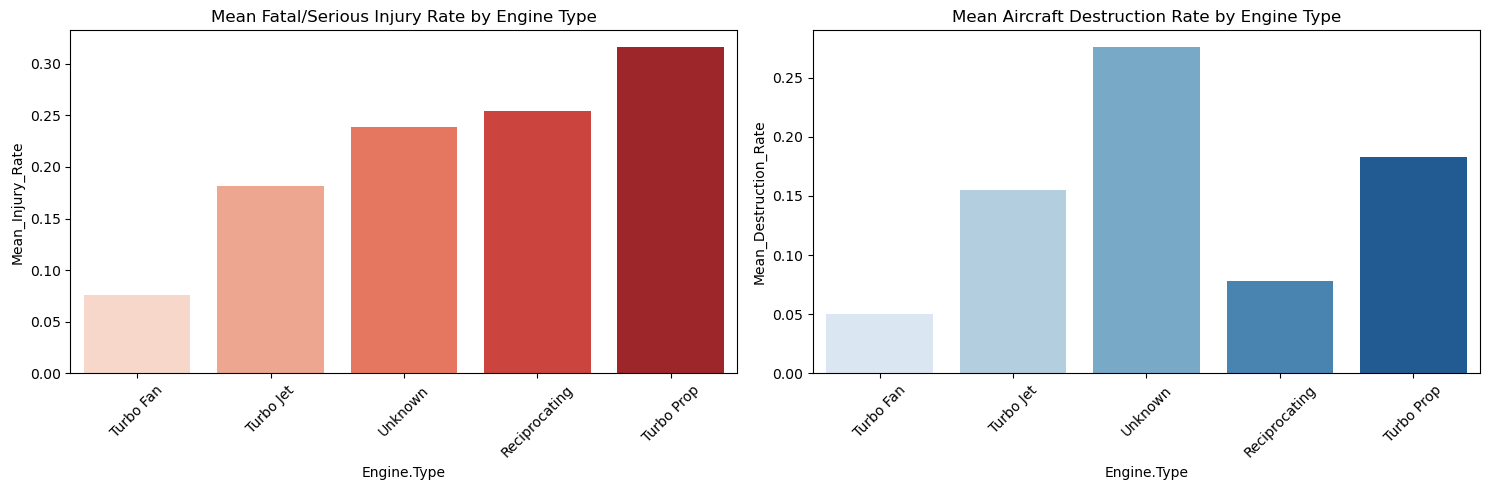

In [21]:
# Engine Type Analysis
engine_summary = (
    aviation_df
    .groupby("Engine.Type")
    .agg(
        Mean_Injury_Rate=("Fatal.Serious.Rate", "mean"),
        Mean_Destruction_Rate=("Destroyed", "mean"),
        Accident_Count=("Destroyed", "count")
    )
    .query("Accident_Count >= 20")
    .sort_values("Mean_Injury_Rate")
)

display(engine_summary)

fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.barplot(
    data=engine_summary.reset_index(),
    x="Engine.Type",
    y="Mean_Injury_Rate",
    hue="Engine.Type",
    legend=False,
    palette="Reds",
    ax=axes[0]
)

axes[0].set_title("Mean Fatal/Serious Injury Rate by Engine Type")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=engine_summary.reset_index(),
    x="Engine.Type",
    y="Mean_Destruction_Rate",
    hue="Engine.Type",
    legend=False,
    palette="Blues",
    ax=axes[1]
)

axes[1].set_title("Mean Aircraft Destruction Rate by Engine Type")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Engine Type

The analysis of engine type indicates that accident outcomes vary across different engine configurations. Among the engine categories examined, **Turbo Fan** aircraft achieved the best overall safety performance, recording the lowest average fatal/serious injury rate (approximately **0.08**) as well as the smallest proportion of aircraft that were completely destroyed (around **0.05**). These results suggest that accidents involving Turbo Fan-powered aircraft generally produce less severe consequences for both passengers and the aircraft.

**Turbo Jet** aircraft also demonstrated relatively favorable safety outcomes, with moderate fatal/serious injury rates and comparatively low destruction rates. On the other hand, **Turbo Prop** aircraft recorded the highest average fatal/serious injury rate (approximately **0.32**) and one of the highest destruction rates, indicating that accidents involving this engine type are more likely to result in severe injuries and significant aircraft damage.

Aircraft equipped with **Reciprocating** engines showed injury rates comparable to those of Turbo Prop aircraft but experienced a lower proportion of complete aircraft destruction. This suggests that, although accidents involving reciprocating engines may still lead to serious injuries, the aircraft is less likely to be totally destroyed. Aircraft with **unknown engine types** recorded the highest destruction rate; however, these findings should be interpreted carefully because the missing engine information may influence the reliability of the results.

Overall, the findings indicate that engine type is associated with both passenger injury severity and the extent of aircraft damage. Based on the available data, Turbo Fan-powered aircraft demonstrated the strongest safety performance, while Turbo Prop aircraft were generally associated with less favorable accident outcomes.
